[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/theochem/grid/blob/master/examples/Quickstart.ipynb)

# Halton Grid

This notebook demonstrates the use of the Halton low-discrepancy sequence
for numerical integration over a three-dimensional cubic domain.

The Halton sequence generates deterministic points in the unit cube
$[0, 1]^3$ using radical-inverse constructions based on successive prime
numbers.

## Constructing a Halton Grid

Imports successful
Number of points: 1000
Point shape: (1000, 3)
Weight shape: (1000,)
Sum of weights: 1.0000000000000004

Integration test
Halton estimate: 0.9958200624208295
Exact value: 1.0
Absolute error: 0.004179937579170456

Dimension tests
1D: (1000, 1)
2D: (1000, 2)
3D: (1000, 3)
5D: (1000, 5)


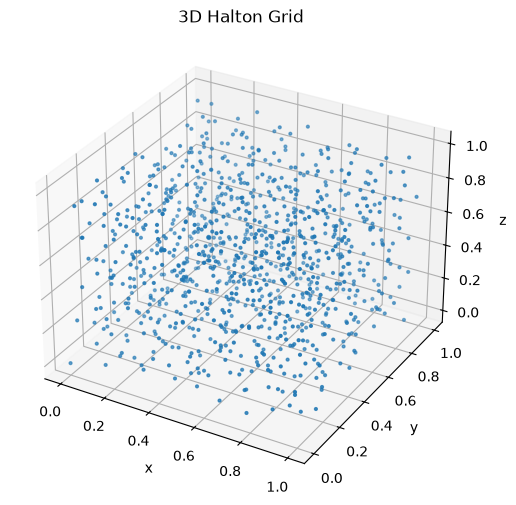


Mapped grid
Minimum: [-3. -3. -3.]
Maximum: [2.99963379 2.99969517 2.999616  ]
Total volume: 216.00000000000006

H2+ model
Atomic coordinates:
[[ 0. -1.  0.]
 [ 0.  1.  0.]]
Internuclear distance: 2.0

Overlap
Analytical: 0.5864528940253216
Numerical: 0.5624658582204711

Normalization
N: 0.5613987115061903
Density integral: 0.9559244321182763


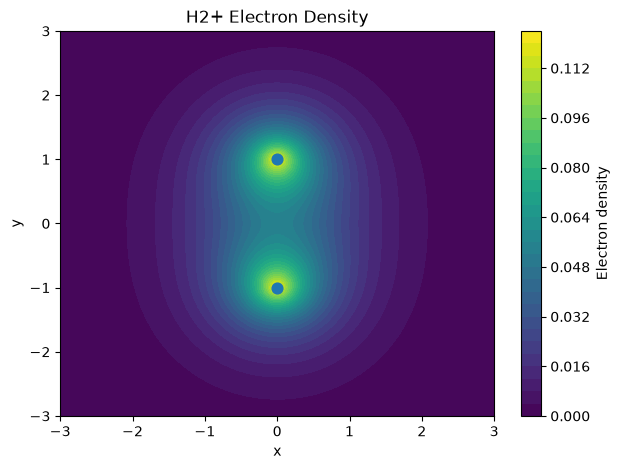


ALL SANITY CHECKS PASSED
Notebook completed successfully.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from grid import Halton

print("Imports successful")

# ============================================================
# 1. Halton grid
# ============================================================

grid = Halton(1000, 3)

print("Number of points:", grid.size)
print("Point shape:", grid.points.shape)
print("Weight shape:", grid.weights.shape)
print("Sum of weights:", grid.weights.sum())

# ============================================================
# 2. Integration test
# Integral of x^2 + y^2 + z^2 over [0,1]^3 = 1
# ============================================================

values = np.sum(grid.points**2, axis=1)

estimate = grid.integrate(values)

print("\nIntegration test")
print("Halton estimate:", estimate)
print("Exact value:", 1.0)
print("Absolute error:", abs(estimate - 1.0))

# ============================================================
# 3. Different dimensions
# ============================================================

print("\nDimension tests")

for ndim in (1, 2, 3, 5):
    grid_nd = Halton(1000, ndim)
    print(f"{ndim}D:", grid_nd.points.shape)

# ============================================================
# 4. Plot Halton points
# ============================================================

grid_3d = Halton(1000, 3)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")

ax.scatter(
    grid_3d.points[:, 0],
    grid_3d.points[:, 1],
    grid_3d.points[:, 2],
    s=4,
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("3D Halton Grid")

plt.show()

# ============================================================
# 5. Map grid from [0,1]^3 to [-3,3]^3
# ============================================================

unit_grid = Halton(20000, 3)

points = 2.0 * unit_grid.points - 1.0
points *= 3.0

weights = unit_grid.weights * 6.0**3

print("\nMapped grid")
print("Minimum:", points.min(axis=0))
print("Maximum:", points.max(axis=0))
print("Total volume:", weights.sum())

# ============================================================
# 6. H2+ two-centre orbital
# ============================================================

atcoords = np.array([
    [0.0, -1.0, 0.0],
    [0.0,  1.0, 0.0],
])

R = np.linalg.norm(atcoords[0] - atcoords[1])

print("\nH2+ model")
print("Atomic coordinates:")
print(atcoords)
print("Internuclear distance:", R)

# 1s orbitals
s1_a_vals = np.sqrt(1.0 / np.pi) * np.exp(
    -np.linalg.norm(points - atcoords[0], axis=1)
)

s1_b_vals = np.sqrt(1.0 / np.pi) * np.exp(
    -np.linalg.norm(points - atcoords[1], axis=1)
)

# ============================================================
# 7. Overlap
# ============================================================

S_ab = (
    1.0
    + R
    + R**2 / 3.0
) * np.exp(-R)

S_ab_num = np.sum(
    weights * s1_a_vals * s1_b_vals
)

print("\nOverlap")
print("Analytical:", S_ab)
print("Numerical:", S_ab_num)

# ============================================================
# 8. Normalization
# ============================================================

N = 1.0 / np.sqrt(2.0 + 2.0 * S_ab)

psi_vals = N * (s1_a_vals + s1_b_vals)

density = psi_vals**2

density_integral = np.sum(weights * density)

print("\nNormalization")
print("N:", N)
print("Density integral:", density_integral)

# ============================================================
# 9. xy-plane electron density
# ============================================================

x = np.linspace(-3.0, 3.0, 100)
y = np.linspace(-3.0, 3.0, 100)

x_grid, y_grid = np.meshgrid(x, y)

plane_points = np.column_stack([
    x_grid.ravel(),
    y_grid.ravel(),
    np.zeros(x_grid.size),
])

s1_a_plane = np.sqrt(1.0 / np.pi) * np.exp(
    -np.linalg.norm(
        plane_points - atcoords[0],
        axis=1
    )
)

s1_b_plane = np.sqrt(1.0 / np.pi) * np.exp(
    -np.linalg.norm(
        plane_points - atcoords[1],
        axis=1
    )
)

psi_plane = N * (
    s1_a_plane + s1_b_plane
)

rho_plane = (
    psi_plane**2
).reshape(x_grid.shape)

# ============================================================
# 10. Plot electron density
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

contour = ax.contourf(
    x_grid,
    y_grid,
    rho_plane,
    levels=30,
)

ax.scatter(
    atcoords[:, 0],
    atcoords[:, 1],
    s=60,
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("H2+ Electron Density")

fig.colorbar(
    contour,
    ax=ax,
    label="Electron density",
)

plt.show()

# ============================================================
# FINAL CHECKS
# ============================================================

assert grid.points.shape == (1000, 3)
assert grid.weights.shape == (1000,)
assert atcoords.shape == (2, 3)
assert np.isfinite(estimate)
assert np.isfinite(S_ab_num)
assert np.isfinite(density_integral)

print("\n===================================")
print("ALL SANITY CHECKS PASSED")
print("Notebook completed successfully.")
print("===================================")